# HR аналитика. Сборный проект.

## Описание проекта

Абсолютно все компании сталкиваются с текучкой кадров. Она возникает как по личным причинам сотрудников, так и в зависимости от внутренних процессов в компании. В данном проекте с помощью машинного обучения поможем бизнесу оптимизировать управление персоналом, избежать финансовых потерь и оттока сотрудников, а также обратить внимание на внутренние процессы в компании, которые на это влияют.

## Цель исследования

Необходимо найти решение для двух задач, которые позволят оценивать уровень удовлетворенности сотрудника и предсказывать его вероятное увольнение. Это позволит вовремя проводить работу с сотрудниками и руководителями подразделений и уменьшить текучку кадров и желание сотрудников работать в компании.

## Ход исследования

В процессе исследования будут проведены следующие действия
- подготовка данных: загрузка и изучение общей информации из предоставленных датасетов
- предобработка данных: обработка пропущенных значений, обработка дублей, корректировка данных
- проведение анализа представленных данных: выявление закономерностей и аномалий, распределения данных по параметрам
- объединение данных в единый датасет и его расширение дополнительной информацией на основе представленных данных
- выявление лучших моделей для задач регрессии и бинарной классификации целевых признаков с использованием пайплайнов
- резюмирование полученных результатов, формулировка общих выводов и рекомендаций

## Настройка окружения

### Импорты

In [1]:
%pip install -Uq scikit-learn
%pip install phik -q
%pip install shap -q

# imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import shap

import warnings
warnings.filterwarnings('ignore', category=pd.core.common.SettingWithCopyWarning)

from phik import phik_matrix
from plotly.subplots import make_subplots
from scipy import stats as st
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    make_scorer,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    LabelEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    PolynomialFeatures,
)

from sklearn.model_selection import (
    train_test_split, 
    GridSearchCV, 
    RandomizedSearchCV
)

# загружаем класс для работы с пропусками
from sklearn.impute import SimpleImputer, KNNImputer

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Настройки отображения

In [79]:
# output settings
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option('display.max_colwidth', None)

### Объявление функций

In [3]:
def check_size(current_df, original_df):
    print("Количество записей: {}".format(len(current_df)))
    print("Процент от начального объема данных: {:.2%}".format(len(current_df) / len(original_df)))

In [4]:
HOST = "https://code.s3.yandex.net"

# load csv
def load_csv(dataset_path, delimiter=",", decimal=".", index_col=None):
    try:
        return pd.read_csv("." + dataset_path, delimiter=delimiter, decimal=decimal, index_col=index_col)
    except Exception:
        return pd.read_csv(HOST + dataset_path, delimiter=delimiter, decimal=decimal, index_col=index_col)

## Загрузка данных

Загрузим предоставленные для исследования данные

In [5]:
train_job_satisfaction_rate_original = load_csv("/datasets/train_job_satisfaction_rate.csv")
train_job_satisfaction_rate_df = train_job_satisfaction_rate_original.copy()
train_job_satisfaction_rate_df.sample(5)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
163,710849,sales,middle,high,5,no,yes,4,54000,0.62
3499,218843,sales,middle,medium,1,no,no,3,42000,0.28
2645,154144,sales,junior,medium,1,no,no,4,25200,0.60
3314,151226,purchasing,middle,medium,4,no,no,5,34800,0.48
1856,261390,marketing,middle,low,4,no,no,4,31200,0.66


In [6]:
test_features_original = load_csv("/datasets/test_features.csv")
test_features_df = test_features_original.copy()
test_features_df.sample(5)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
676,708917,technology,junior,medium,1,no,no,4,27600
1483,757913,sales,sinior,high,10,yes,no,5,81600
1746,572119,hr,junior,low,2,no,no,2,19200
241,624788,purchasing,junior,medium,1,no,no,4,22800
830,582749,marketing,junior,low,1,no,no,3,13200


In [7]:
test_target_job_satisfaction_rate_original = load_csv("/datasets/test_target_job_satisfaction_rate.csv")
test_target_job_satisfaction_rate_df = test_target_job_satisfaction_rate_original.copy()
test_target_job_satisfaction_rate_df.sample(5)

,id,job_satisfaction_rate
636,756011,0.65
1726,529698,0.20
1099,799349,0.66
1139,201582,0.27
263,344889,0.69


In [8]:
train_quit_original = load_csv("/datasets/train_quit.csv")
train_quit_df = train_quit_original.copy()
train_quit_df.sample(5)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
3954,619324,sales,middle,high,7,no,yes,3,56400,no
301,429344,marketing,middle,high,4,no,no,3,55200,no
3462,130836,sales,middle,high,6,no,yes,2,45600,no
1240,789478,sales,junior,low,3,no,no,4,18000,no
1307,423505,marketing,junior,low,1,no,no,4,20400,no


In [9]:
test_target_quit_original = load_csv("/datasets/test_target_quit.csv")
test_target_quit_df = test_target_quit_original.copy()
test_target_quit_df.sample(5)

,id,quit
736,386153,no
1611,535704,yes
1461,108816,no
1600,594345,no
189,624693,no


Данные загружены. Данные в таблицах соответствуют описанию.

## Предобработка данных

### Первичный анализ таблиц

In [10]:
df_dict = {
    "train_job_satisfaction_rate_df": train_job_satisfaction_rate_df,
    "test_features_df": test_features_df,
    "test_target_job_satisfaction_rate_df": test_target_job_satisfaction_rate_df,
    "train_quit_df": train_quit_df,
    "test_target_quit_df": test_target_quit_df,
}

In [11]:
for df_name, df in df_dict.items():
    print("=" * 50)
    print(f"{df_name}:\n")
    display(df.info())
    display(df.describe())

train_job_satisfaction_rate_df:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


None

,id,employment_years,supervisor_evaluation,salary,job_satisfaction_rate
count,"4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,"544,957.62",3.72,3.48,"33,926.70",0.53
std,"257,883.10",2.54,1.01,"14,900.70",0.23
min,"100,954.00",1.00,1.00,"12,000.00",0.03
25%,"322,836.75",2.00,3.00,"22,800.00",0.36
50%,"534,082.50",3.00,4.00,"30,000.00",0.56
75%,"771,446.00",6.00,4.00,"43,200.00",0.71
max,"999,521.00",10.00,5.00,"98,400.00",1.00


test_features_df:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


None

...

None

,id,employment_years,supervisor_evaluation,salary
count,"4,000.00","4,000.00","4,000.00","4,000.00"
mean,"552,099.28",3.70,3.47,"33,805.80"
std,"260,158.03",2.54,1.00,"15,152.42"
min,"100,222.00",1.00,1.00,"12,000.00"
25%,"327,785.75",2.00,3.00,"22,800.00"
50%,"546,673.00",3.00,4.00,"30,000.00"
75%,"781,497.75",6.00,4.00,"43,200.00"
max,"999,915.00",10.00,5.00,"96,000.00"


test_target_quit_df:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


None

,id
count,"2,000.00"
mean,"552,765.21"
std,"253,851.33"
min,"100,298.00"
25%,"339,052.00"
50%,"550,793.00"
75%,"765,763.75"
max,"999,029.00"


Имена столбцов корректные. Типы данных определены верно. Явных выбросов не наблюдается. Есть несколько пропусков в столбцах `dept` и `level`.

### Обработка пропусков

Найдем и выведем данные с пропущенными значениями

In [12]:
def print_df_na(df_name, df):
    # Создаем маску для строк с NaN
    mask = df.isna().any(axis=1)
    if mask.sum() > 0:
        # Выводим строки с пропущенными значениями
        rows_with_na = df.loc[mask]
        print("=" * 50)
        print(f"{df_name}:\n")
        print("Строки с пропущенными значениями:")
        display(rows_with_na)

In [13]:
for df_name, df in df_dict.items():
    print_df_na(df_name, df)

train_job_satisfaction_rate_df:

Строки с пропущенными значениями:


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
1209,631073,sales,NaN,medium,1,no,no,4,27600,0.66
1469,416327,sales,NaN,low,1,no,no,5,18000,0.73
1526,694746,NaN,junior,medium,5,no,no,4,21600,0.62
1630,814624,NaN,junior,medium,3,no,no,4,24000,0.88
1633,475114,NaN,junior,high,4,no,no,4,31200,0.63
1745,135043,sales,NaN,medium,1,no,no,3,26400,0.30
2522,998838,sales,NaN,medium,1,no,no,5,27600,0.71
2781,497243,NaN,junior,medium,1,no,no,3,26400,0.28
2975,168668,NaN,junior,low,3,no,no,4,18000,0.88
3866,641150,NaN,junior,low,3,no,yes,4,12000,0.54


test_features_df:

Строки с пропущенными значениями:


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
191,609865,NaN,junior,medium,1,no,no,1,20400
312,471990,sales,NaN,low,1,no,no,3,12000
1196,832342,NaN,junior,medium,1,no,no,4,28800


Будем заполнять пропущенные значения с помощью пайплайна и трансформера. Непосредственно заполнение пропусков будет произведено на этапе обучения моделей с использованием пайплайнов. На данном этапе просто объявим инструменты для заполнения пропусков.

In [14]:
na_cols = ["dept", "level"]

missing_values_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(missing_values=np.nan, strategy="most_frequent")),
    ],
)

na_transformer = ColumnTransformer(
    transformers=[
        ("na", missing_values_pipe, na_cols),
    ],
    remainder="passthrough",
)

# train_job_satisfaction_rate_na_df = pd.DataFrame(
#     na_transformer.fit_transform(train_job_satisfaction_rate_df.copy()[na_cols]),
#     columns=na_cols,
# )

# test_features_na_df = pd.DataFrame(
#     na_transformer.fit_transform(test_features_df.copy()[na_cols]),
#     columns=na_cols,
# )

# train_job_satisfaction_rate_df[na_cols] = train_job_satisfaction_rate_na_df[na_cols]
# test_features_df[na_cols] = test_features_na_df[na_cols]

# for df_name, df in df_dict.items():
#     print_df_na(df_name, df)

### Наличие дубликатов

Проверим наличие явных дубликатов

In [15]:
def print_df_duplicates(df_name, df):
    # Создаем маску для строк с дубликатами
    mask = df.duplicated()
    if mask.sum() > 0:
        # Выводим дубликаты
        print("=" * 50)
        print(f"\n{df_name}: total: {mask.sum()}\n")
        display(df[mask].head())
    return mask.sum()

In [16]:
df_train_dict={
    "train_job_satisfaction_rate_df": train_job_satisfaction_rate_df,
    "train_quit_df": train_quit_df,
}

duplicates_count = 0
for df_name, df in df_train_dict.items():
    duplicates_count += print_df_duplicates(df_name, df)
if duplicates_count == 0:
    print("Явных дубликтов не обнаружено")

Явных дубликтов не обнаружено


Проверим наличие неявных дубликатов в категориальных признаках

In [17]:
for df_name, df in df_dict.items():
    for df_column_name in list(df.select_dtypes(exclude="number").columns):
        print(f'Список уникальных значений в {df_name}.{df_column_name}:\n{df[df_column_name].unique()}\n')

Список уникальных значений в train_job_satisfaction_rate_df.dept:
['sales' 'hr' 'technology' 'purchasing' 'marketing' nan]

Список уникальных значений в train_job_satisfaction_rate_df.level:
['junior' 'middle' 'sinior' nan]

Список уникальных значений в train_job_satisfaction_rate_df.workload:
['medium' 'high' 'low']

Список уникальных значений в train_job_satisfaction_rate_df.last_year_promo:
['no' 'yes']

Список уникальных значений в train_job_satisfaction_rate_df.last_year_violations:
['no' 'yes']

Список уникальных значений в test_features_df.dept:
['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' ']

Список уникальных значений в test_features_df.level:
['junior' 'middle' 'sinior' nan]

Список уникальных значений в test_features_df.workload:
['medium' 'low' 'high' ' ']

Список уникальных значений в test_features_df.last_year_promo:
['no' 'yes']

Список уникальных значений в test_features_df.last_year_violations:
['no' 'yes']

Список уникальных значений в train_quit_df.dept:

Присутствуют опечатки (`sinior` вместо `senior`) и пустые строки пробелов. Исправим опечатки, а пустые строки обработаем в пайплайнах инструментами энкодеров.

In [18]:
typos = {
    "sinior": "senior",
    # " ": np.nan
}

train_job_satisfaction_rate_df.level = train_job_satisfaction_rate_df.level.replace(typos)
test_features_df.dept = test_features_df.dept.replace(typos)
test_features_df.level = test_features_df.level.replace(typos)
test_features_df.workload = test_features_df.workload.replace(typos)
train_quit_df.level = train_quit_df.level.replace(typos)

for df_name, df in df_dict.items():
    for df_column_name in list(df.select_dtypes(exclude="number").columns):
        print(f'Список уникальных значений в {df_name}.{df_column_name}:\n{df[df_column_name].unique()}\n')

Список уникальных значений в train_job_satisfaction_rate_df.dept:
['sales' 'hr' 'technology' 'purchasing' 'marketing' nan]

Список уникальных значений в train_job_satisfaction_rate_df.level:
['junior' 'middle' 'senior' nan]

Список уникальных значений в train_job_satisfaction_rate_df.workload:
['medium' 'high' 'low']

Список уникальных значений в train_job_satisfaction_rate_df.last_year_promo:
['no' 'yes']

Список уникальных значений в train_job_satisfaction_rate_df.last_year_violations:
['no' 'yes']

Список уникальных значений в test_features_df.dept:
['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' ']

Список уникальных значений в test_features_df.level:
['junior' 'middle' 'senior' nan]

Список уникальных значений в test_features_df.workload:
['medium' 'low' 'high' ' ']

Список уникальных значений в test_features_df.last_year_promo:
['no' 'yes']

Список уникальных значений в test_features_df.last_year_violations:
['no' 'yes']

Список уникальных значений в train_quit_df.dept:

Теперь все выглядит корректно. Пустые строки из пробелов и значения nan будут заполнены с использованием пайплайнов в шаге Подготовка данных. Для обработки пустых строк в пайплайне воспользуемся трансформером ниже

In [19]:
missing_space_values_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(missing_values=" ", strategy="most_frequent")),
    ],
)

### Ошибки в числовых значениях

In [20]:
negative_values_flag = False
for df_name, df in df_dict.items():
    for df_column_name in list(df.select_dtypes(include="number").columns):
        if df[df_column_name][df[df_column_name] < 0].count() > 0:
            print(f'Количество отрицательных значений в {df_name}.{df_column_name}: {df[df_column_name][df[df_column_name] < 0].count()}')
            negative_values_flag = True
if not negative_values_flag:
    print("Отрицательные значения отсутствуют")

Отрицательные значения отсутствуют


### Полнота данных

Проверим полноту данных после проведения предобработки

In [21]:
check_size(train_job_satisfaction_rate_df, train_job_satisfaction_rate_original)
check_size(test_features_df, test_features_original)
check_size(test_target_job_satisfaction_rate_df, test_target_job_satisfaction_rate_original)
check_size(train_quit_df, train_quit_original)
check_size(test_target_quit_df, test_target_quit_original)

Количество записей: 4000
Процент от начального объема данных: 100.00%
Количество записей: 2000
Процент от начального объема данных: 100.00%
Количество записей: 2000
Процент от начального объема данных: 100.00%
Количество записей: 4000
Процент от начального объема данных: 100.00%
Количество записей: 2000
Процент от начального объема данных: 100.00%


Объем данных не изменился

### Промежуточные выводы

В ходе предварительной обработки данных было сделано следующее:
- проведена проверка на наличие пропусков в данных, пропуски обнаружены, будут обработаны с использованием пайплайнов
- проведена проверка на наличие явных и неявных дубликатов, ошибки в категориальных данных устранены, строки из пробелов заменены на значение `nan`
- проведена проверка на наличие неявных ошибок в числовых данных, ошибок не выявлено
- проведена проверка на полноту данных после предобработки

Дальнейшие шаги будем проводить в разрезе каждой из задач

# Задача 1: предсказание уровня удовлетворённости сотрудника

## Исследовательский анализ данных

### Количественные признаки

Введем новый категориальный признак удовлетворенности сотрудников. Будем отталкиваться от следующих значений:
- ниже либо равно 0.35, неудовлетворен
- от 0.35 до 0.65, нейтрально
- выше либо равно 0.65, удовлетворен

In [22]:
def get_job_satisfaction_cat(value):
    if value <= 0.35:
        return "неудовлетворен"
    if 0.35 < value and value <= 0.65:
        return "нейтрально"
    return "удовлетворен"


train_job_satisfaction_rate_df["job_satisfaction_cat"] = train_job_satisfaction_rate_df[
    "job_satisfaction_rate"
].apply(lambda x: get_job_satisfaction_cat(x))

train_job_satisfaction_rate_df["job_satisfaction_cat"].sample(5)

3783    неудовлетворен
1319      удовлетворен
241       удовлетворен
261         нейтрально
3032    неудовлетворен
Name: job_satisfaction_cat, dtype: object

Построим гистограмму распределения и "ящик с усами" для количественных признаков `train_job_satisfaction_rate_df` в зависимости от категориального признака удовлетворенности `job_satisfaction_cat`

In [23]:
# количество корзин в зависимости от количества уникальных значений
def get_bins_count(value):
    if value > 100:
        return value // 10
    return value

Создадим необходимые функции для отображения графиков

In [24]:
# histogram
def get_histogram(df, df_column_name, df_target_column_name):
    fig = px.histogram(
        df, 
        x=df_column_name, 
        color=df_target_column_name,
        color_discrete_map={
            'неудовлетворен': 'Coral',
            'нейтрально': 'lightyellow',
            'удовлетворен': 'SeaGreen',
        },
        nbins=get_bins_count(df[df_column_name].nunique())
    )

    fig.update_layout(
        title_text=f"Гистограмма распределения {df_column_name}",
        xaxis_title_text=f"{df_column_name}",
        yaxis_title_text="Кол-во",
        barmode='group',
        legend_title=None,
    )

    fig.show()

In [25]:
# boxplot
def get_boxplot(df, df_column_name, df_target_column_name):
    fig = go.Figure()

    fig.add_trace(
        go.Box(
            x=df[df_target_column_name == "неудовлетворен"][
                df_column_name
            ],
            name="неудовлетворен",
            line=dict(color="red"),
            fillcolor="Coral",
        )
    )

    fig.add_trace(
        go.Box(
            x=df[df_target_column_name == "нейтрально"][
                df_column_name
            ],
            name="нейтрально",
            line=dict(color="yellow"),
            fillcolor="lightyellow",
        )
    )

    fig.add_trace(
        go.Box(
            x=df[df_target_column_name == "удовлетворен"][
                df_column_name
            ],
            name="удовлетворен",
            line=dict(color="green"),
            fillcolor="SeaGreen",
        )
    )

    fig.update_layout(
        title_text=f"Распределение значений {df_column_name}",
        xaxis_title_text=f"{df_column_name}",
        legend_title=None,
    )

    fig.show()

In [26]:
def get_histogram_boxplot(df, df_column_name, df_target_column_name):
    get_histogram(df, df_column_name, df_target_column_name)
    get_boxplot(df, df_column_name, df_target_column_name)

In [27]:
for df_column_name in train_job_satisfaction_rate_df.select_dtypes(include="number").drop(["id", "job_satisfaction_rate"], axis=1).columns:
    get_histogram_boxplot(
        train_job_satisfaction_rate_df,
        df_column_name,
        train_job_satisfaction_rate_df.job_satisfaction_cat,
    )

Отдельно стоит отметить интересный выброс, когда руководство высоко оценивает работу сотрудника, но сотрудник при этом неудовлетворен.

Найдем и исследуем данные по сотруднику.

In [28]:
train_job_satisfaction_rate_df.query("job_satisfaction_cat == 'неудовлетворен' & supervisor_evaluation == 5")

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,job_satisfaction_cat
2178,156430,sales,middle,low,3,no,yes,5,19200,0.35,неудовлетворен


Сотрудник 3 года работает в отделе продаж на позиции middle. У него низкая загрузка и за последний год не было повышений. Посмотрим на зарплату других сотрудников в отделе

In [29]:
train_job_satisfaction_rate_df.query("dept == 'sales'").pivot_table(
    index=["level"],
    columns=["workload"],
    values=["salary"],
    aggfunc=[
        "max",
        "min",
        "mean",
        "median",
    ],
).reset_index()

level    max                  min                    mean  \
                 salary               salary                  salary   
workload           high    low medium   high    low medium      high   
0         junior  38400  19200  28800  30000  12000  20400 33,426.09   
1         middle  60000  30000  44400  45600  18000  31200 52,221.43   
2         senior  79200  39600  60000  62400  25200  43200 70,430.77   

                             median                
                             salary                
workload       low    medium   high    low medium  
0        14,885.22 24,247.24  33600  14400  24000  
1        23,941.75 38,224.68  52800  24000  38400  
2        34,854.55 50,770.59  69600  37200  51600

Сотрудник работает на позиции middle, а получает как junior. Возможно, руководитель недостаточно внимателен к конкретному сотруднику либо между ними конфликт.

Дополнительно посмотрим на сотрудников, которые работают в компании больше 8 лет

In [30]:
train_job_satisfaction_rate_df.query("job_satisfaction_cat == 'неудовлетворен' & employment_years > 8").sample(10)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,job_satisfaction_cat
2119,434152,marketing,middle,high,9,no,no,3,54000,0.30,неудовлетворен
3375,545058,hr,middle,low,9,no,no,2,19200,0.34,неудовлетворен
2200,608119,marketing,middle,medium,10,no,yes,3,36000,0.11,неудовлетворен
3079,295893,sales,middle,low,10,no,no,3,18000,0.33,неудовлетворен
3648,712494,sales,senior,medium,10,no,no,3,44400,0.29,неудовлетворен
3331,252174,sales,senior,low,9,no,no,3,31200,0.32,неудовлетворен
3781,901962,technology,middle,high,9,no,no,2,61200,0.34,неудовлетворен
845,654235,technology,middle,medium,9,no,no,3,39600,0.35,неудовлетворен
1197,283112,sales,senior,medium,10,no,no,3,44400,0.31,неудовлетворен
1278,453350,technology,senior,medium,10,no,no,3,52800,0.35,неудовлетворен


In [31]:
check_size(train_job_satisfaction_rate_df.query("job_satisfaction_cat == 'неудовлетворен' & employment_years > 8"), train_job_satisfaction_rate_df)

Количество записей: 34
Процент от начального объема данных: 0.85%


Эти сотрудники давно работают в компании, но имеют низкую оценку со стороны руководства. Как следствие, оплата труда ниже среднего и отсутствие повышений в последний год. Возможно, они не достаточно компетентные или им просто неинтересно.

Таких сотрудников всего 34, меньше 1%. Имеет смысл обсудить ситуацию с их руководителями и каждым из них в индивидуальном порядке.

### Промежуточные выводы

Из графиков можно сделать следующие выводы:
- доля удовлетворенных сотрудников выглядит низкой в начале работы в компании, высокой в период около 2х лет работы и после 5 лет работы. Видимо, нелояльные сотрудники увольняются в первые 2 года работы. А в период от 2х до 5 лет людям, видимо, просто хочется перемен.
- доля нелояльных сотрудников выглядит высокой в начале работы. Вероятно, это связано с внутренними процессами компании и/или расхождением ожиданий с действительностью
- неудовлетворенность сотрудников и оценка качества работы со стороны руководителя выглядят взаимосвязанными признаками
- уровень удовлетворенности зависит от вознаграждения. Чем ниже вознаграждение, тем ниже уровень удовлетворенности

Стоит обратить особое внимание на сотрудника с id=156430, и выяснить у руководителя больше деталей про ситуацию с ним. Что-то тут не так.

Ситуацию с недовольными сотрудниками, которые давно работают в компании, имеет смысл обсуждать индивидуально с каждым из них и их руководителями.

### Категориальные признаки

Проведем анализ категориальных признаков

Объявим необходимые функции для построения столбчатых и круговых диаграмм

In [32]:
def get_bar(df, df_column_name, df_target_column_name):
    fig = px.bar(
        df,
        x=df_column_name,
        y='count',
        color=df_target_column_name,
        color_discrete_map={
            'неудовлетворен': 'Coral',
            'нейтрально': 'lightyellow',
            'удовлетворен': 'SeaGreen',
        },
    )

    fig.update_layout(
        title_text=f"Распределение {df_column_name}",
        yaxis_title_text=f"{df_column_name}",
        xaxis_title_text="Кол-во",
        barmode="group",
        legend_title=None,
    )

    fig.show()

In [33]:
def get_pie(df, df_column_name, df_target_column_name):
    unique_values_count = df[df_column_name].nunique()
    unique_values_list = list(df[df_column_name].unique())

    pie_specs = [{"type": "pie"}] * unique_values_count

    # Создание сетки для диаграмм
    fig = make_subplots(
        rows=1,
        cols=unique_values_count,
        specs=[pie_specs],
        subplot_titles=unique_values_list,
    )

    for col_num in range(1, unique_values_count + 1):
        filter = df[df_column_name] == unique_values_list[col_num - 1]
        filtered_df = df[filter]

        # Добавление диаграммы
        fig.add_trace(
            go.Pie(
                labels=filtered_df[df_target_column_name], 
                values=filtered_df["count"],
                marker=dict(colors=['lightyellow', 'Coral', 'SeaGreen']),
            ),
            row=1, col=col_num
        )
    
    fig.update_layout(
        title_text=f"Распределение {df_column_name}",
    )

    fig.show()

In [34]:
def get_bar_pie(df, df_column_name, df_target_column_name):
    get_bar(df, df_column_name, df_target_column_name)
    get_pie(df, df_column_name, df_target_column_name)

Построим диаграммы для категориальных признаков в разрезе целевого признака

In [35]:
for df_column_name in train_job_satisfaction_rate_df.select_dtypes(exclude="number").drop(columns=["job_satisfaction_cat"], axis=1).columns:
    train_job_satisfaction_rate_grouped_df = train_job_satisfaction_rate_df.groupby(by=["job_satisfaction_cat", df_column_name])['id'].count().reset_index()
    train_job_satisfaction_rate_grouped_df.rename(columns={'id': 'count'}, inplace=True)

    get_bar_pie(train_job_satisfaction_rate_grouped_df, df_column_name, "job_satisfaction_cat")

### Промежуточные выводы

На основании столбчатых и круговых диаграмм можно сделать следующие выводы:
- в отделах `sales` и `technology` доля неудовлетворенных сотрудников выше. Возможно, на это влияют условия оплаты труда и/или низкая оценка работы со стороны руководства
- среди специалистов уровня `senior` доля неудовлетворенных сотрудников выше. На это также могут оказывать влияние условия оплаты труда и/или низкая оценка работы со стороны руководства
- доля неудовлетворенных сотрудников выше среди сотрудников со средней нагрузкой, а минимальная -- с высокой. Возможно, сотрудникам скучно и хотелось бы более сложных и интересных задач, проявить себя
- среди сотрудников, которые не получили повышение за последний год, доля неудовлетворенных выше. Тут все логично. Сотрудникам хочется повышения в должности и повышения оплаты труда.
- аналогично с нарушающими трудовой договор. Доля неудовлетворенных сотрудников выше среди тех, кто совершал нарушения. Тут тоже все логично.

## Сравнение тренировочных и тестовых данных

In [36]:
# Получение описательной статистики
train_data = train_job_satisfaction_rate_df.drop(columns=["id", "job_satisfaction_rate"], axis=1)
train_stats = train_data.describe()
print("Train:")
display(train_stats.T)

test_data = test_features_original.drop("id", axis=1)
test_stats = test_data.describe()
print("Test:")
display(test_stats.T)

Train:


,count,mean,std,min,25%,50%,75%,max
employment_years,"4,000.00",3.72,2.54,1.00,2.00,3.00,6.00,10.00
supervisor_evaluation,"4,000.00",3.48,1.01,1.00,3.00,4.00,4.00,5.00
salary,"4,000.00","33,926.70","14,900.70","12,000.00","22,800.00","30,000.00","43,200.00","98,400.00"


Test:


,count,mean,std,min,25%,50%,75%,max
employment_years,"2,000.00",3.67,2.54,1.00,1.00,3.00,6.00,10.00
supervisor_evaluation,"2,000.00",3.53,1.00,1.00,3.00,4.00,4.00,5.00
salary,"2,000.00","34,066.80","15,398.44","12,000.00","22,800.00","30,000.00","43,200.00","96,000.00"


Статистика по тренировочным и тестовым данным выглядит похожей

Сравним распределения значений

In [37]:
train_num_data_columns = train_data.select_dtypes(include="number").columns.tolist()
unique_num_values_count = len(train_num_data_columns)

# Создание сетки для диаграмм
fig = make_subplots(
    rows=1,
    cols=unique_num_values_count,
    subplot_titles=train_num_data_columns,
)

# Визуальное сравнение распределений
for col_num in range(1, unique_num_values_count + 1):

    fig.add_trace(
        go.Histogram(
            name=f"train {train_num_data_columns[col_num - 1]}",
            x=train_data[train_num_data_columns[col_num - 1]],
            marker_color="SeaGreen"
        ),
        row=1,
        col=col_num,
    )

    fig.add_trace(
        go.Histogram(
            name=f"test {train_num_data_columns[col_num - 1]}",
            x=test_data[train_num_data_columns[col_num - 1]],
            marker_color="Coral"
        ),
        row=1,
        col=col_num,
    )

    fig.update_layout(
        barmode="group",
    )

fig.show()

Распределение значений по количественным признакам выглядит похоже

Сравним категориальные признаки

In [38]:
train_cat_data_columns = train_data.drop("job_satisfaction_cat", axis=1).select_dtypes(exclude="number").columns.tolist()
unique_cat_values_count = len(train_cat_data_columns)

# Создание сетки для диаграмм
fig = make_subplots(
    rows=1,
    cols=unique_cat_values_count,
    subplot_titles=train_cat_data_columns,
)

# Визуальное сравнение распределений
for col_num in range(1, unique_cat_values_count + 1):
    
    fig.add_trace(
        go.Bar(
            name=f"train {train_cat_data_columns[col_num - 1]}",
            x=train_data[train_cat_data_columns[col_num - 1]].value_counts().index,
            y=train_data[train_cat_data_columns[col_num - 1]].value_counts(normalize=True),
            marker_color="SeaGreen",
        ),
        row=1,
        col=col_num,
    )

    fig.add_trace(
        go.Bar(
            name=f"test {train_cat_data_columns[col_num - 1]}",
            x=train_data[train_cat_data_columns[col_num - 1]].value_counts().index,
            y=test_data[train_cat_data_columns[col_num - 1]].value_counts(normalize=True),
            marker_color="Coral",
        ),
        row=1,
        col=col_num,
    )

    fig.update_layout(barmode='group')
fig.show()

Распределение значений по категориальным признакам тоже выглядит похоже

### Промежуточные выводы

На основании представленных выше графиков можно сделать вывод, что тренировочные и тестовые данные "похожи"

## Корреляционный анализ

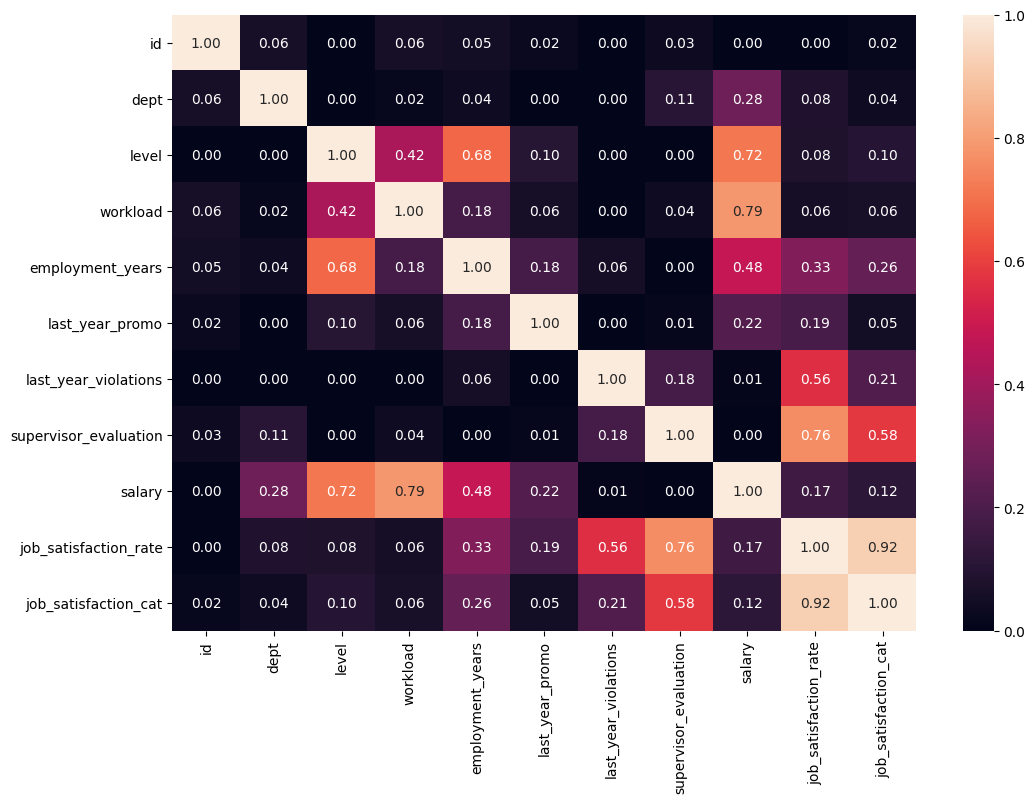

In [39]:
# выделим колонки с количественными и категориальными данными
num_columns = list(train_job_satisfaction_rate_df.select_dtypes(include="number").columns)

# построим матрицу корреляции
correlation_matrix = train_job_satisfaction_rate_df.phik_matrix(interval_cols=num_columns , verbose=False)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f');

Мультиколлинеарности признаков (с коэффициентом зависимости больше 0.9) не наблюдается. Признак `job_satisfaction_cat` в расчет не берем, т.к. этот признак был создан на базе целевого и для обучения моделей будет исключен из датасета.

Судя по матрице корреляции, целевой признак (`job_satisfaction_rate`) слабо зависит от следующих признаков (коэффициент зависимости меньше либо равен 0.3):
- dept
- level
- workload
- last_year_promo
- salary

Умеренно либо сильно зависит от:
- employment_years
- last_year_violations
- supervisor_evaluation

Также стоит отметить, что на зарплату сотрудников оказывают влияние уровень, нагрузка и количество лет в компании. А уровень сотрудников зависит от количества лет в компании и рабочей нагрузки. Это выглядит логично, никаких сюрпризов.

### Промежуточные выводы

Матрица корреляции показала заметную или сильную зависимость целевого признака (уровень удовлетворённости сотрудника работой в компании) от оценки качества работы сотрудника и нарушений трудового договора. В меньшей степени от количества лет в компании.

Из этого можно сделать вывод, что на уровень удовлетворенности влияет в первую очередь внимание к конкретному человеку и его работе в компании. Нарушения трудового договора, скорее всего, являются следствием отсутствия необходимого внимания к сотруднику.

## Обучение моделей

Исключим признак `job_satisfaction_cat` из датасета. Он больше не нужен.

In [40]:
train_job_satisfaction_rate_df = train_job_satisfaction_rate_df.drop(columns=["job_satisfaction_cat"], axis=1)
list(train_job_satisfaction_rate_df.columns)

['id',
 'dept',
 'level',
 'workload',
 'employment_years',
 'last_year_promo',
 'last_year_violations',
 'supervisor_evaluation',
 'salary',
 'job_satisfaction_rate']

Изменим индексы в таблицах на поле `id`, удалим дубли после изменения индекса и выделим целевой признак в тестовой выборке. Дубли имеет смысл удалить, т.к. ценности для модели такие наблюдения не несут

In [41]:
train_job_rate_df = train_job_satisfaction_rate_df.set_index(keys=["id"])
print("Duplicates count:", train_job_rate_df.duplicated().sum())
train_job_rate_clean_df = train_job_rate_df.drop_duplicates()

X_train_job_rate = train_job_rate_clean_df.drop(columns=["job_satisfaction_rate"], axis=1)
display(train_job_rate_clean_df.head())
y_train_job_rate = train_job_rate_clean_df["job_satisfaction_rate"]
display(y_train_job_rate.head())

Duplicates count: 245


,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.58
653870,hr,junior,high,2,no,no,5,38400,0.76
184592,sales,junior,low,1,no,no,2,12000,0.11
171431,technology,junior,low,4,no,no,2,18000,0.37
693419,hr,junior,medium,1,no,no,3,22800,0.20


id
155278   0.58
653870   0.76
184592   0.11
171431   0.37
693419   0.20
Name: job_satisfaction_rate, dtype: float64

Изменим индексы, объединим таблицы и выделим целевой признак для тестовой выборки

In [42]:
# поменяем индексы
test_job_rate_df = test_features_df.set_index(keys=["id"])
test_target_job_rate_df = test_target_job_satisfaction_rate_df.set_index(keys=["id"])
# объединим таблицы
test_full_job_rate_df = test_job_rate_df.join(test_target_job_rate_df)
display(test_full_job_rate_df.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800,0.79
686555,hr,junior,medium,1,no,no,4,30000,0.72
467458,sales,middle,low,5,no,no,4,19200,0.64
418655,sales,middle,low,6,no,no,4,19200,0.60
789145,hr,middle,medium,5,no,no,5,40800,0.75


In [43]:
# разобъем на выборки
X_test_job_rate = test_full_job_rate_df.drop(columns=["job_satisfaction_rate"], axis=1)
display(X_test_job_rate.head())
y_test_job_rate = test_full_job_rate_df["job_satisfaction_rate"]
display(y_test_job_rate.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800
686555,hr,junior,medium,1,no,no,4,30000
467458,sales,middle,low,5,no,no,4,19200
418655,sales,middle,low,6,no,no,4,19200
789145,hr,middle,medium,5,no,no,5,40800


id
485046   0.79
686555   0.72
467458   0.64
418655   0.60
789145   0.75
Name: job_satisfaction_rate, dtype: float64

In [44]:
X_train_job_rate.shape, X_test_job_rate.shape, y_train_job_rate.shape, y_test_job_rate.shape

((3755, 8), (2000, 8), (3755,), (2000,))

Теперь выборки готовы к дальнейшей обработке и обучению моделей

Разобьем признаки на категориальные и количественные. Для OneHotEncoder и OrdinalEncoder.

In [45]:
RANDOM_STATE = 1

cat_columns = list(X_train_job_rate.select_dtypes(exclude="number").columns)
print("cat_columns:", cat_columns)

num_columns = list(X_train_job_rate.select_dtypes(include="number").columns)
print("num_columns:", num_columns)

ohe_columns = [
    "dept",
    "last_year_promo",
    "last_year_violations",
]
print("ohe_columns:", ohe_columns)

ord_columns = [
    "level",
    "workload",
]
print("ord_columns:", ord_columns)

na_cols = [
    "dept",
    "level",
]
print("na_cols:", na_cols)

cat_columns: ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations']
num_columns: ['employment_years', 'supervisor_evaluation', 'salary']
ohe_columns: ['dept', 'last_year_promo', 'last_year_violations']
ord_columns: ['level', 'workload']
na_cols: ['dept', 'level']


Реализуем логику метрики SMAPE

In [46]:
def smape_score(y_true, y_pred):
    return 100 / len(y_pred) * np.sum(2 * np.abs(y_true - y_pred) / (np.abs(y_pred) + np.abs(y_true)))

smape_scorer = make_scorer(smape_score, greater_is_better=False)

Подготовим пайплайны

In [47]:
# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков и OHE-кодирование
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [
        (
            "simpleImputer_ohe",
            missing_values_pipe,
        ),
#         (
#             "simpleImputer_space_ohe",
#             missing_space_values_pipe,
#         ),
        (
            "ohe",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ],
)

# cоздаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков и Ordinal-кодирование
# SimpleImputer + OE
ord_pipe = Pipeline(
    [
        (
            "simpleImputer_before_ord",
            missing_values_pipe,
        ),
        (
            "ord",
            OrdinalEncoder(
                categories=[
                    ["junior", "middle", "senior"],
                    ["low", "medium", "high"],
                ],
                handle_unknown="use_encoded_value",
                unknown_value=np.nan,
            ),
        ),
        (
            "simpleImputer_after_ord",
            missing_values_pipe,
        ),
    ],
)

In [50]:
# пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', MinMaxScaler(), num_columns),
    ], 
    remainder='passthrough'
)

# итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline(
    [
        ("preprocessor", data_preprocessor),
        ("models", DecisionTreeRegressor(random_state=RANDOM_STATE)),
    ]
)

Подготовим словари для моделей данных

In [51]:
param_grid = [
    # словарь для модели DecisionTreeRegressor()
    {
        "models": [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        "models__max_depth": range(2, 20),
        "models__min_samples_split": range(2, 20),
        "preprocessor__num": [StandardScaler(), MinMaxScaler(), "passthrough"],
    },
    # словарь для модели LinearRegression()
    {
        "models": [LinearRegression()],
        "models__fit_intercept": [True, False],
        "preprocessor__num": [StandardScaler(), MinMaxScaler(), "passthrough"],
    },
]

Обучим модели и получим лучший результат. Будем использовать RandomizedSearchCV как самый быстрый. В качестве метрики для оценки качества моделей будем использовать метрику SMAPE

In [52]:
randomized_search = RandomizedSearchCV(
    pipe_final,
    param_grid,
    n_iter=30,
    cv=5,
    scoring=smape_scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
randomized_search.fit(X_train_job_rate.copy(), y_train_job_rate.copy())

print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print('Метрика лучшей модели на кросс-валидации:', -1 * randomized_search.best_score_)

# проверим работу модели на тестовой выборке
y_test_pred = randomized_search.predict(X_test_job_rate.copy())
print(f'Метрика SMAPE на тестовой выборке: {smape_score(y_test_job_rate.copy(), y_test_pred)}')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='most_frequent'))])),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                               

c:\Users\mkhld\anaconda\envs\practicum\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning:

Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros



Получим топ-10 лучших моделей для анализа

In [53]:
search_results_df = pd.DataFrame(randomized_search.cv_results_)

# Топ-10 лучших результатов
top_10_results = search_results_df.sort_values(by='rank_test_score').head(10)

# Вывод основных метрик
print("Топ-10 лучших комбинаций параметров:")
top_10_results

Топ-10 лучших комбинаций параметров:


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessor__num,param_models__min_samples_split,param_models__max_depth,param_models,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
2,0.04,0.00,0.02,0.00,MinMaxScaler(),6,19,DecisionTreeRegressor(random_state=1),"{'preprocessor__num': MinMaxScaler(), 'models_...",-15.19,-13.96,-16.11,-15.91,-14.33,-15.10,0.85,1
5,0.03,0.00,0.02,0.00,passthrough,11,17,DecisionTreeRegressor(random_state=1),"{'preprocessor__num': 'passthrough', 'models__...",-15.36,-14.77,-15.71,-15.53,-14.48,-15.17,0.47,2
11,0.03,0.01,0.01,0.00,MinMaxScaler(),12,17,DecisionTreeRegressor(random_state=1),"{'preprocessor__num': MinMaxScaler(), 'models_...",-15.07,-14.81,-15.74,-15.80,-14.45,-15.17,0.53,3
14,0.02,0.00,0.01,0.00,StandardScaler(),13,17,DecisionTreeRegressor(random_state=1),"{'preprocessor__num': StandardScaler(), 'model...",-15.12,-14.70,-15.95,-15.61,-14.61,-15.20,0.52,4
4,0.03,0.00,0.01,0.00,passthrough,13,19,DecisionTreeRegressor(random_state=1),"{'preprocessor__num': 'passthrough', 'models__...",-15.07,-14.72,-15.89,-15.67,-14.66,-15.20,0.50,5
1,0.04,0.00,0.02,0.00,passthrough,9,15,DecisionTreeRegressor(random_state=1),"{'preprocessor__num': 'passthrough', 'models__...",-15.30,-14.47,-16.02,-15.93,-14.52,-15.25,0.66,6
9,0.02,0.00,0.01,0.00,passthrough,13,13,DecisionTreeRegressor(random_state=1),"{'preprocessor__num': 'passthrough', 'models__...",-15.65,-14.81,-15.89,-15.49,-14.87,-15.34,0.43,7
6,0.03,0.00,0.01,0.00,MinMaxScaler(),16,19,DecisionTreeRegressor(random_state=1),"{'preprocessor__num': MinMaxScaler(), 'models_...",-15.44,-14.92,-16.05,-15.72,-14.75,-15.37,0.49,8
22,0.02,0.00,0.01,0.00,StandardScaler(),16,13,DecisionTreeRegressor(random_state=1),"{'preprocessor__num': StandardScaler(), 'model...",-15.90,-14.77,-16.06,-15.80,-14.92,-15.49,0.54,9
20,0.02,0.00,0.01,0.00,StandardScaler(),15,11,DecisionTreeRegressor(random_state=1),"{'preprocessor__num': StandardScaler(), 'model...",-16.00,-14.94,-16.06,-15.65,-15.46,-15.62,0.41,10


Из топ-10 видно, что самая лучшая модель самая "нестабильная". Стадартное отклонение значения метрики составляет 0.85, что является самым большим значением из всех. Но при этом наблюдаем довольно существенный (относительный) разрыв по среднему значению метрики на валидации между лучшей моделью и второй.

### Промежуточные выводы

- Разбили признаки на категориальные и количественные. Категориальные признаки в свою очередь разбили для использования разными энкодерами, OneHotEncoder и OrdinalEncoder
- Реализовали метрику SMAPE для оценки моделей
- Составили пайплайн, заполнили пропуски в данных и нашли лучшую модель и ее гиперпараметры для задачи регрессии

Лучшей признана модель регрессионного дерева решений со следующими параметрами

DecisionTreeRegressor(max_depth=19, min_samples_split=6, random_state=1)

Несмотря на ее относительную нестабильность, она показала самое лучшее среднее значение метрики на кросс-валидации

SMAPE показала значение 15.10 на тренировочной выборке и значение 13.93 на тестовой. Значение на тестовой выборке соответствует требованиям в задаче

## Анализ важности признаков

Построим SHAP диаграммы для оценки влияния признаков на целевой

In [54]:
preprocessor = randomized_search.best_estimator_.named_steps['preprocessor']
model = randomized_search.best_estimator_.named_steps['models']

c:\Users\mkhld\anaconda\envs\practicum\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning:

Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros



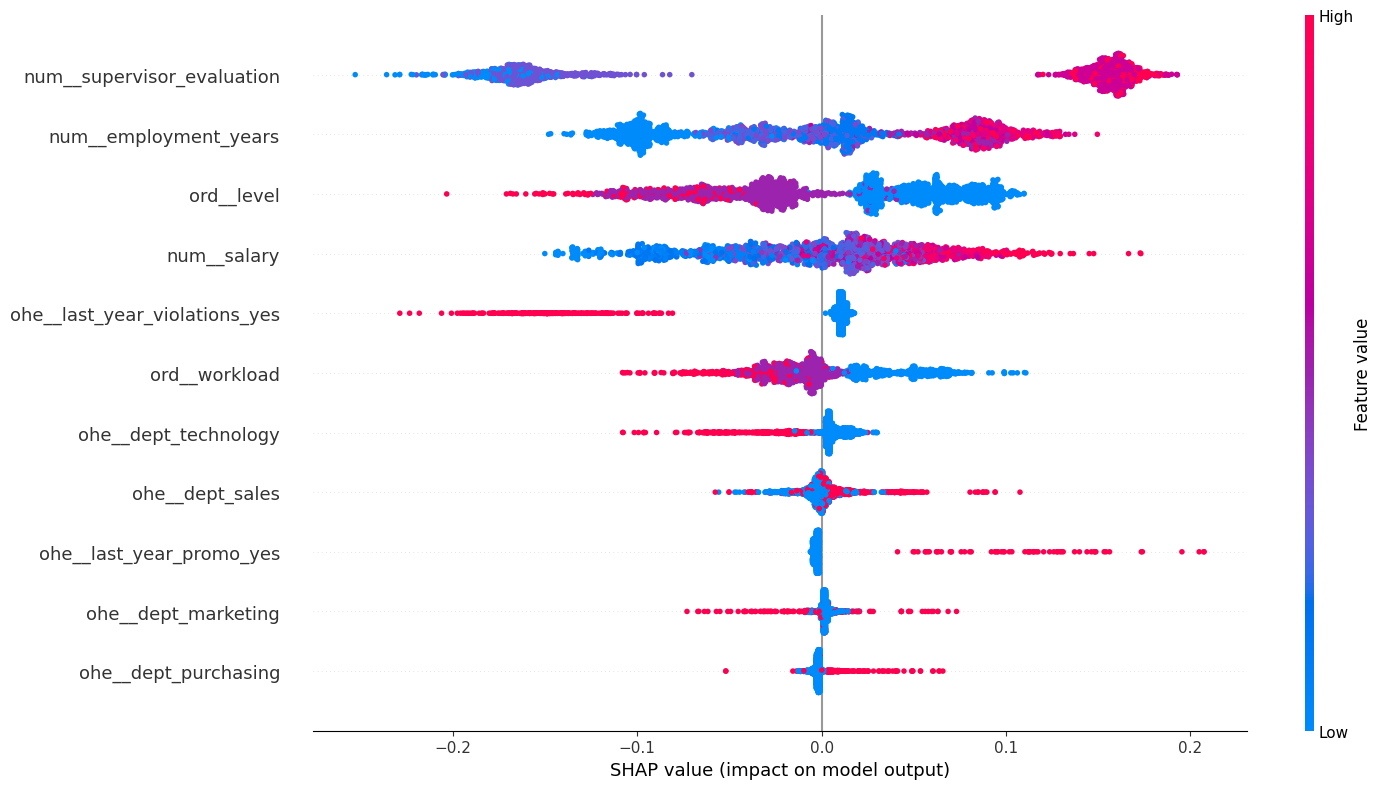

In [55]:
original_features = list(X_train_job_rate.columns)

X_test_piped = preprocessor.transform(X_test_job_rate.copy())
explainer = shap.Explainer(model, X_test_piped)
feature_names = preprocessor.get_feature_names_out()
shap_values = explainer(X_test_piped, check_additivity=False)
 
shap.summary_plot(shap_values, X_test_piped, feature_names=feature_names, max_display=15, plot_size=(15, 8))

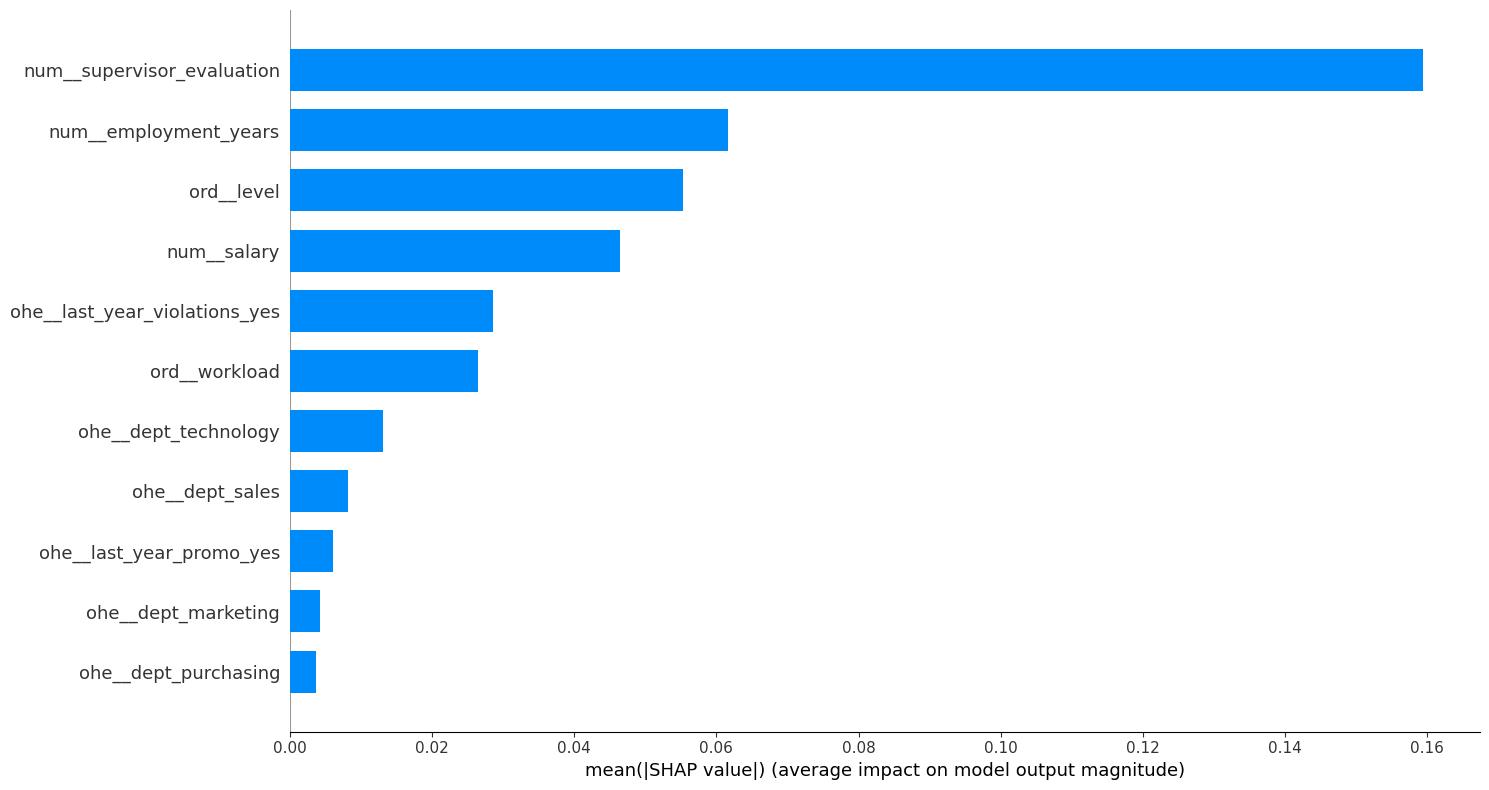

In [56]:
shap.summary_plot(shap_values, X_test_piped, plot_type="bar", feature_names=feature_names, max_display=15, plot_size=(15, 8))

### Промежуточные выводы

На SHAP диаграммах видно, что на Уровень удовлетворённости сотрудника работой в компании сильнее всего влияет Оценка качества работы сотрудника, которую дал руководитель. А нарушения трудового договора говорит о неудволетворенности. Это подтверждает выдвинутые ранее предположения.

Дополнительно стоит отметить, что на уровень удовлетворенности также оказывают влияние следующие признаки:
- количество лет работы в компании. Чем больше, тем выше удовлетворенность. Это закономерно, т.к. в компании задерживаются на долгий срок преимущественно лояльные сотрудники, а нелояльные увольняются (вероятно) в первые два года. Это было отмечено в ходе исследовательского анализа данных.
- уровень сотрудника. Чем выше, тем ниже удовлетворенность. Вероятно, с увеличением квалификации сотрудника, растет и уровень претензий к компании. Это косвенно подтверждает утверждение про оценку качества работы и вообще внимание к сотруднику со стороны руководителей.
- уровень зарплаты. Чем выше зарплата, тем выше уровень удовлетворенности. Тут все логично, никаких неожиданностей.
- уровень нагрузки. Высокий уровень нагрузки чаще связан с интересом и сложностью задач, что приводит к развитию и повышению квалификации, а значит и уровню дохода сотрудника и степенью удовлетворенности от работы. Тут тоже все логично.

# Задача 2: предсказание увольнения сотрудника из компании

Предобработка данных была выполнена ранее. Выполним исследовательский анализ данных

## Исследовательский анализ данных

Проведем анализ количественных признаков

### Количественные признаки

Переопределим необходимые для построения графиков функции

In [57]:
# histogram
def get_histogram(df, df_column_name, df_target_column_name):
    fig = px.histogram(
        df, 
        x=df_column_name, 
        color=df_target_column_name,
        color_discrete_map={
            'yes': 'Coral',
            'no': 'SeaGreen',
        },
        nbins=get_bins_count(df[df_column_name].nunique())
    )

    fig.update_layout(
        title_text=f"Гистограмма распределения {df_column_name}",
        xaxis_title_text=f"{df_column_name}",
        yaxis_title_text="Кол-во",
        barmode='group',
        legend_title=None,
    )

    fig.show()

In [58]:
# boxplot
def get_boxplot(df, df_column_name, df_target_column_name):
    fig = go.Figure()

    fig.add_trace(
        go.Box(
            x=df[df_target_column_name == "yes"][
                df_column_name
            ],
            name="yes",
            line=dict(color="red"),
            fillcolor="Coral",
        )
    )

    fig.add_trace(
        go.Box(
            x=df[df_target_column_name == "no"][
                df_column_name
            ],
            name="no",
            line=dict(color="green"),
            fillcolor="SeaGreen",
        )
    )

    fig.update_layout(
        title_text=f"Распределение значений {df_column_name}",
        xaxis_title_text=f"{df_column_name}",
        legend_title=None,
    )

    fig.show()

Построим гистограмму распределения и "ящик с усами" для количественных признаков в зависимости от категориального признака `quit`

In [59]:
for df_column_name in train_quit_df.select_dtypes(include="number").drop(columns=["id"], axis=1).columns:
    get_histogram_boxplot(
        train_quit_df,
        df_column_name,
        train_quit_df.quit,
    )

### Промежуточные выводы

Уволившийся сотрудник премущественно:
- проработал в компании не больше 2х лет
- имел низкий уровень оплаты труда (в потора раз ниже, чем неуволившийся)
- имел низкую оценку со стороны руководителя (3 и ниже)

### Категориальные признаки

Проведем анализ категориальных признаков. Для этого сначала переопределим необходимые фукнции для построения графиков

In [60]:
def get_bar(df, df_column_name, df_target_column_name):
    fig = px.bar(
        df,
        x=df_column_name,
        y='count',
        color=df_target_column_name,
        color_discrete_map={
            'yes': 'Coral',
            'no': 'SeaGreen',
        },
    )

    fig.update_layout(
        title_text=f"Распределение {df_column_name}",
        yaxis_title_text=f"{df_column_name}",
        xaxis_title_text="Кол-во",
        barmode="group",
        legend_title=None,
    )

    fig.show()

In [61]:
def get_pie(df, df_column_name, df_target_column_name):
    unique_values_count = df[df_column_name].nunique()
    unique_values_list = list(df[df_column_name].unique())

    pie_specs = [{"type": "pie"}] * unique_values_count

    # Создание сетки для диаграмм
    fig = make_subplots(
        rows=1,
        cols=unique_values_count,
        specs=[pie_specs],
        subplot_titles=unique_values_list,
    )

    for col_num in range(1, unique_values_count + 1):
        filter = df[df_column_name] == unique_values_list[col_num - 1]
        filtered_df = df[filter]

        # Добавление диаграммы
        fig.add_trace(
            go.Pie(
                labels=filtered_df[df_target_column_name], 
                values=filtered_df["count"],
                marker=dict(colors=['SeaGreen', 'Coral']),
            ),
            row=1, col=col_num
        )

    fig.update_layout(
        title_text=f"Распределение {df_column_name}",
    )

    fig.show()

Построим столбчатую и круговую диграммы

In [62]:
train_quit_df.groupby(by=["dept"])["quit"].value_counts(normalize=True)

dept        quit
hr          no     0.75
            yes    0.25
marketing   no     0.72
            yes    0.28
purchasing  no     0.72
            yes    0.28
sales       no     0.72
            yes    0.28
technology  no     0.70
            yes    0.30
Name: quit, dtype: float64

In [63]:
for df_column_name in train_quit_df.select_dtypes(exclude="number").drop(columns=["quit"], axis=1).columns:
    train_quit_grouped_df = train_quit_df.groupby(by=["quit", df_column_name])['id'].count().reset_index(name="count")

    get_bar_pie(train_quit_grouped_df, df_column_name, "quit")

На основании круговых диаграмм, уволившийся сотрудник:
- работает в отделе technology (почти 30% уволившихся сотрудников)
- работал на позиции junior (больше 50%)
- с низкой загрузкой (43%)
- без продвижения за последний год (почти 30%)
- нарушающий трудовой договор (26%)

Посмотрим также диаграммы по уволившимся сотрудникам в зависимости от признака удовлетворенности. Для этого необходимо добавить этот признак в таблицу. Поскольку для выборки с признаком увольнения этого признака нет и эти данные содержат информацию о сотрудниках, которые не входят в выборку из задания 1, смоделируем эти данные с помощью натренированной модели.

In [64]:
test_quit_df = test_features_df.copy()
test_quit_df.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


In [65]:
# поменяем индексы
test_quit_reindex_df = test_quit_df.set_index("id")
test_target_quit_reindex_df = test_target_quit_df.set_index("id")

# с помощью модели добавим признак job_satisfaction_rate
test_quit_reindex_transformed_df = preprocessor.transform(test_quit_reindex_df.copy())
test_quit_reindex_df["job_satisfaction_rate"] = model.predict(request=test_quit_reindex_transformed_df)

# объединим таблицы
test_quit_reindex_full_df = test_quit_reindex_df.join(test_target_quit_reindex_df)
test_quit_reindex_full_df.head()

c:\Users\mkhld\anaconda\envs\practicum\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning:

Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros



,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
id,,,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800,0.89,no
686555,hr,junior,medium,1,no,no,4,30000,0.68,no
467458,sales,middle,low,5,no,no,4,19200,0.65,no
418655,sales,middle,low,6,no,no,4,19200,0.66,no
789145,hr,middle,medium,5,no,no,5,40800,0.81,no


Построим диаграммы для признака удовлетворенности

In [66]:
get_histogram_boxplot(test_quit_reindex_full_df, "job_satisfaction_rate", test_quit_reindex_full_df["quit"])

Никаких сюрпризов. Низкий уровень удовлетворенности (примерно 0.5 для 75% случаев и ниже) влияет на увольнение сотрудника.

Стоит также отметить выброс, когда уволился человек с рассчитанным уровнем удовлетворенности 0.98.

### Промежуточные выводы

На основании анализа количественных и категориальных признаков можно составить "портрет" уволившегося сотрудника:
- проработал в компании не больше 2х лет
- имел низкий уровень оплаты труда (в потора раз ниже, чем оставшийся)
- имел низкую оценку со стороны руководителя (3 и ниже)
- работает в отделе technology (почти 30% уволившихся сотрудников)
- работает на позиции junior (больше 50%)
- с низкой загрузкой (43%)
- без продвижения за последний год (почти 30%)
- нарушающий трудовой договор (26%)
- с низким уровнем удовлетворенности сотрудника (примерно 0.5 и ниже)

Перейдем к корреляционному анализу

## Корреляционный анализ

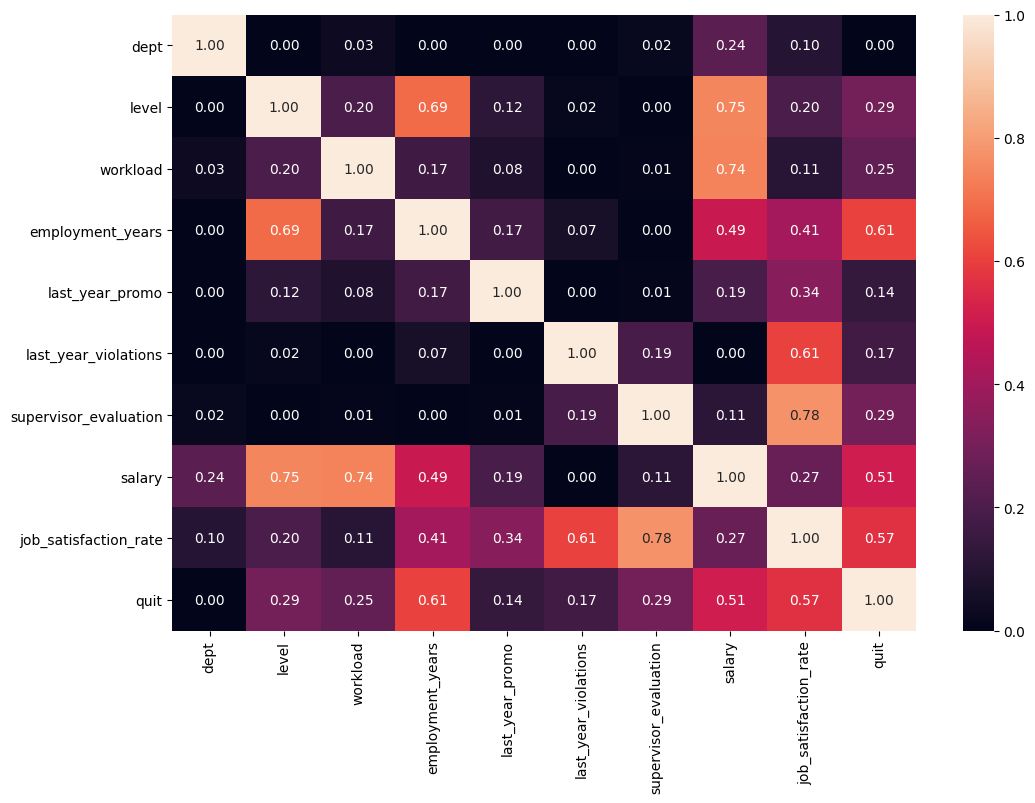

In [67]:
# выделим колонки с количественными и категориальными данными
num_columns = list(test_quit_reindex_full_df.select_dtypes(include="number").columns)

# построим матрицу корреляции
correlation_matrix = test_quit_reindex_full_df.phik_matrix(interval_cols=num_columns , verbose=False)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f');

Мультиколлинеарности признаков (с коэффициентом зависимости больше 0.9) не наблюдается.

Судя по матрице корреляции, целевой признак (`quit`) слабо зависит от следующих признаков (коэффициент зависимости меньше либо равен 0.3):
- dept
- level
- workload
- last_year_promo
- last_year_violations
- supervisor_evaluation

Умеренно либо сильно зависит от:
- employment_years
- salary
- job_satisfaction_rate

### Промежуточные выводы

Матрица корреляции показала заметную или сильную зависимость целевого признака (увольнение сотрудника из компании) от количества лет в компании, зарплаты и уровня удовлетворенности. В меньшей степени от уровня занимаемой позиции.

Это дополнительно подтверждает выводы, сделанные на предыдущих шагах анализа.

## Подготовка данных к обучению моделей

Подготовим тестовые данные, разобъем на выборки по признакам

In [68]:
X_test_quit = test_quit_reindex_full_df.drop("quit", axis=1)
display(X_test_quit.head())

y_test_quit = test_quit_reindex_full_df["quit"]
display(y_test_quit.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800,0.89
686555,hr,junior,medium,1,no,no,4,30000,0.68
467458,sales,middle,low,5,no,no,4,19200,0.65
418655,sales,middle,low,6,no,no,4,19200,0.66
789145,hr,middle,medium,5,no,no,5,40800,0.81


id
485046    no
686555    no
467458    no
418655    no
789145    no
Name: quit, dtype: object

Подготовим тренировочные данные, рассчитаем признак `job_satisfaction_rate` с помощью модели из задания 1

In [69]:
train_quit_reindex_df = train_quit_df.set_index("id")

X_train_quit = train_quit_reindex_df.drop("quit", axis=1)
display(X_train_quit.head())

y_train_quit = train_quit_reindex_df["quit"]
display(y_train_quit.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000
814010,sales,junior,medium,2,no,no,4,27600
155091,purchasing,middle,medium,5,no,no,1,37200
257132,sales,junior,medium,2,no,yes,3,24000
910140,marketing,junior,medium,2,no,no,5,25200


id
723290     no
814010     no
155091     no
257132    yes
910140     no
Name: quit, dtype: object

In [70]:
X_train_quit_transformed = preprocessor.transform(X_train_quit.copy())
X_train_quit["job_satisfaction_rate"] = model.predict(request=X_train_quit_transformed)
X_train_quit.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,0.60
814010,sales,junior,medium,2,no,no,4,27600,0.85
155091,purchasing,middle,medium,5,no,no,1,37200,0.34
257132,sales,junior,medium,2,no,yes,3,24000,0.34
910140,marketing,junior,medium,2,no,no,5,25200,0.69


In [72]:
X_train_quit.shape, X_test_quit.shape, y_train_quit.shape, y_test_quit.shape

((4000, 9), (2000, 9), (4000,), (2000,))

Данные готовы к обучению моделей

## Обучение моделей

Подготовим функцию для создания пайплайна и обучения моделей

In [73]:
def create_pipe_get_random_search(ohe_columns, ord_columns, num_columns):
    # Подготовим пайплайны
    # создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков и OHE-кодирование
    # SimpleImputer + OHE
    ohe_pipe = Pipeline(
        [
            (
                "simpleImputer_ohe",
                missing_values_pipe,
            ),
#             (
#                 "simpleImputer_space_ohe",
#                 missing_space_values_pipe,
#             ),
            (
                "ohe",
                OneHotEncoder(
                    drop="first", 
                    handle_unknown="ignore", 
                    sparse_output=False
                ),
            ),
        ]
    )

    # cоздаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков и Ordinal-кодирование
    # SimpleImputer + OE
    ord_pipe = Pipeline(
        [
            (
                "simpleImputer_before_ord",
                missing_values_pipe,
            ),
            (
                "ord",
                OrdinalEncoder(
                    categories=[
                        ["junior", "middle", "senior"],
                        ["low", "medium", "high"],
                    ],
                    handle_unknown="use_encoded_value",
                    unknown_value=np.nan,
                ),
            ),
            (
                "simpleImputer_after_ord",
                missing_values_pipe,
            ),
        ]
    )

    # пайплайн для подготовки данных
    data_preprocessor = ColumnTransformer(
        [
            ("ohe", ohe_pipe, ohe_columns),
            ("ord", ord_pipe, ord_columns),
            ("num", MinMaxScaler(), num_columns),
        ],
        remainder="passthrough",
    )

    # итоговый пайплайн: подготовка данных и модель
    pipe_final = Pipeline(
        [
            ("preprocessor", data_preprocessor),
            ("models", DecisionTreeClassifier(random_state=RANDOM_STATE)),
        ]
    )

    # Подготовим словари для моделей данных
    param_grid = [
        # словарь для модели DecisionTreeClassifier()
        {
            "models": [DecisionTreeClassifier(random_state=RANDOM_STATE)],
            "models__max_depth": range(2, 20),
            "models__max_features": range(2, 20),
            "preprocessor__num": [StandardScaler(), MinMaxScaler(), RobustScaler(), "passthrough"],
        },
        # словарь для модели LogisticRegression()
        {
            "models": [
                LogisticRegression(
                    random_state=RANDOM_STATE,
                    solver="liblinear"
                )
            ],
            "models__C": range(1, 5),
            "preprocessor__num": [StandardScaler(), MinMaxScaler(), RobustScaler(), "passthrough"],
        },
        # словарь для модели SVC()
        {
            "models": [
                SVC(random_state=RANDOM_STATE, kernel="linear", probability=True)
            ],
            "models__C": range(2, 5),
            "preprocessor__num": [StandardScaler(), MinMaxScaler(), RobustScaler(), "passthrough"],
        },
    ]

    randomized_search = RandomizedSearchCV(
        pipe_final,
        param_grid,
        n_iter=40,
        cv=5,
        scoring="roc_auc",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    return randomized_search

Разобьем признаки на категориальные и количественные. Для OneHotEncoder и OrdinalEncoder.

In [74]:
RANDOM_STATE = 1

cat_columns = list(X_train_quit.select_dtypes(exclude="number").columns)
print("cat_columns:", cat_columns)

num_columns = list(X_train_quit.select_dtypes(include="number").columns)
print("num_columns:", num_columns)

ohe_columns = [
    "dept",
    "last_year_promo",
    "last_year_violations",
]
print("ohe_columns:", ohe_columns)

ord_columns = [
    "level",
    "workload",
]
print("ord_columns:", ord_columns)

cat_columns: ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations']
num_columns: ['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']
ohe_columns: ['dept', 'last_year_promo', 'last_year_violations']
ord_columns: ['level', 'workload']


In [75]:
randomized_search = create_pipe_get_random_search(ohe_columns, ord_columns, num_columns)
randomized_search.fit(X_train_quit, y_train_quit)

print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print('Метрика лучшей модели на кросс-валидации:', randomized_search.best_score_)

# проверим работу модели на тестовой выборке
y_test_pred = randomized_search.predict_proba(X_test_quit)[:,1]
print(f'Метрика ROC_AUC_SCORE на тестовой выборке: {roc_auc_score(y_test_quit, y_test_pred)}')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='most_frequent'))])),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                               

c:\Users\mkhld\anaconda\envs\practicum\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning:

Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros



ROC_AUC_SCORE на тестовой выборке составляет 0.93, что соответствует требованию в задании.

Получим топ-10 моделей для анализа

In [76]:
search_results_df = pd.DataFrame(randomized_search.cv_results_)

# Топ-10 лучших результатов
top_10_results = search_results_df.sort_values(by='rank_test_score').head(10)

# Вывод основных метрик
print("Топ-10 лучших комбинаций параметров:")
top_10_results

Топ-10 лучших комбинаций параметров:


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessor__num,param_models__max_features,param_models__max_depth,param_models,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
21,0.16,0.01,0.10,0.00,passthrough,11,5,DecisionTreeClassifier(random_state=1),"{'preprocessor__num': 'passthrough', 'models__...",0.93,0.92,0.93,0.92,0.94,0.93,0.01,1
38,0.13,0.01,0.06,0.00,passthrough,7,4,DecisionTreeClassifier(random_state=1),"{'preprocessor__num': 'passthrough', 'models__...",0.92,0.91,0.93,0.92,0.94,0.92,0.01,2
18,0.17,0.01,0.13,0.01,MinMaxScaler(),11,4,DecisionTreeClassifier(random_state=1),"{'preprocessor__num': MinMaxScaler(), 'models_...",0.91,0.91,0.93,0.92,0.93,0.92,0.01,3
33,0.19,0.01,0.10,0.01,RobustScaler(),13,4,DecisionTreeClassifier(random_state=1),"{'preprocessor__num': RobustScaler(), 'models_...",0.92,0.91,0.93,0.92,0.93,0.92,0.01,4
26,0.20,0.01,0.09,0.02,StandardScaler(),3,6,DecisionTreeClassifier(random_state=1),"{'preprocessor__num': StandardScaler(), 'model...",0.92,0.92,0.92,0.91,0.93,0.92,0.00,5
16,0.14,0.01,0.09,0.01,RobustScaler(),4,6,DecisionTreeClassifier(random_state=1),"{'preprocessor__num': RobustScaler(), 'models_...",0.91,0.92,0.92,0.91,0.94,0.92,0.01,6
34,0.20,0.01,0.12,0.01,RobustScaler(),18,7,DecisionTreeClassifier(random_state=1),"{'preprocessor__num': RobustScaler(), 'models_...",0.90,0.92,0.89,0.91,0.92,0.91,0.01,7
36,0.16,0.00,0.11,0.01,passthrough,11,3,DecisionTreeClassifier(random_state=1),"{'preprocessor__num': 'passthrough', 'models__...",0.90,0.89,0.91,0.90,0.92,0.90,0.01,8
14,0.17,0.01,0.08,0.00,RobustScaler(),19,3,DecisionTreeClassifier(random_state=1),"{'preprocessor__num': RobustScaler(), 'models_...",0.90,0.89,0.91,0.90,0.92,0.90,0.01,8
3,0.15,0.01,0.06,0.01,passthrough,12,3,DecisionTreeClassifier(random_state=1),"{'preprocessor__num': 'passthrough', 'models__...",0.90,0.89,0.91,0.90,0.92,0.90,0.01,8


Лучшая модель показала стабильные результаты на кросс-валидации (std_test_score = 0.01).

### Промежуточные выводы

- Удалили дубли в тренировочных данных
- Разбили признаки на категориальные и количественные. Категориальные признаки в свою очередь разбили для использования разными энкодерами, OneHotEncoder и OrdinalEncoder
- Использовали ROC-AUC метрику для оценки моделей
- Составили пайплайн, заполнили пропуски в данных и нашли лучшую модель и ее гиперпараметры для задачи регрессии

Лучшей признана модель регрессионного дерева решений со следующими параметрами
DecisionTreeClassifier(max_depth=5, max_features=11, random_state=1)

ROC-AUC показала значение 0.93 на тренировочной выборке и значение 0.93 на тестовой. Значение на тестовой выборке соответствует требованиям в задаче

## Анализ важности признаков

In [77]:
preprocessor = randomized_search.best_estimator_.named_steps['preprocessor']
model = randomized_search.best_estimator_.named_steps['models']

In [78]:
X_train_quit_piped = preprocessor.fit_transform(X_train_quit.copy())
feature_names = preprocessor.get_feature_names_out()

# Получение важности признаков
model.fit(X_train_quit_piped, y_train_quit)
feature_importances = model.feature_importances_

# Вывод результатов
feature_importances_df = pd.DataFrame(data=zip(feature_names, feature_importances), columns=["feature", "importance"])
feature_importances_df.sort_values(by="importance", ascending=False)

,feature,importance
6,ord__level,0.38
11,num__job_satisfaction_rate,0.38
7,ord__workload,0.13
8,num__employment_years,0.06
10,num__salary,0.05
9,num__supervisor_evaluation,0.01
4,ohe__last_year_promo_yes,0.00
2,ohe__dept_sales,0.00
0,ohe__dept_marketing,0.00
1,ohe__dept_purchasing,0.00


### Промежуточные выводы

На основании анализа важности признаков для модели видно, что на увольнение сотрудников из компании влияют следующие признаки:
- level
- job_satisfaction_rate
- workload
- employment_years
- supervisor_evaluation
- salary

Эти данные подтверждают выводы, сделанные на шаге Исследовательский анализ данных. Несмотря на то, что качество модели соответствует заявленным требованиям, ее качество можно попробовать улучшить, если удалить из датасета колонки, важность которых составляет 0.

## Общий вывод

В данной работе был проведен анализ HR данных крупной компании для выявления возможностей оптимизировать управление персоналом, избежать финансовых потерь и оттока сотрудников.

Выполнена предобработка данных:
- обработаны пропуски и дубликаты
- обработаны неявные ошибки в данных

Проведен исследовательский анализ данных количественных и категориальных признаков в разрезе признаков "уровень удовлетворённости сотрудника работой в компании" и "увольнение сотрудника из компании".

Уровень удовлетворённости сотрудника работой в компании:
- в отделах `sales` и `technology` доля неудовлетворенных сотрудников выше
- среди специалистов уровня `senior` доля неудовлетворенных сотрудников выше
- доля неудовлетворенных сотрудников выше среди сотрудников со средней нагрузкой, а минимальная -- с высокой
- среди сотрудников, которые не получили повышение за последний год, доля неудовлетворенных выше
- доля неудовлетворенных сотрудников выше среди тех, кто совершал нарушения

Увольнение сотрудника из компании:
- проработал в компании не больше 2х лет
- низкий уровень оплаты труда (в потора раз ниже, чем у остающихся)
- низкая оценка со стороны руководителя (3 и ниже)
- работа в отделе technology (почти 30% уволившихся сотрудников)
- работа на позиции junior (больше 50%)
- с низкой загрузкой (43%)
- без продвижения за последний год (почти 30%)
- нарушающий трудовой договор (26%)
- с низким уровнем удовлетворенности сотрудника (примерно 0.5 и ниже)

Проведен анализ важности признаков и их влияния на целевые признаки. На основании анализа признаков можно выделить следующее:

Уровень удовлетворённости сотрудника работой в компании:
- оценка качества работы сотрудника
- нарушения трудового договора
- количество лет работы в компании. Чем больше, тем выше удовлетворенность
- уровень сотрудника. Чем выше, тем ниже удовлетворенность
- уровень зарплаты. Чем ниже зарплата, тем ниже уровень удовлетворенности
- уровень нагрузки. Чем вышу нагрузка, тем выше удовлетворенность

Увольнение сотрудника из компании:
- уровень сотрудника
- оценка качества работы сотрудника
- количество лет работы в компании
- уровень удовлетворённости сотрудника
- уровень нагрузки
- уровень зарплаты

Таким образом, на основании проведенной работы можно дать следующие рекомендации:
- чаще привлекать сотрудников к сложным и интересным задачам
- профессиональное развитие сотрудников за счет тренингов и обучений
- повышать уровень оплаты труда на основании результатов работы
- пересмотреть отношение к оценке качества работы сотрудника (введение KPI)
- процессы внутри компании должны быть прозрачными и понятными для сотрудников

Отдельно стоит отметить, что нарушения трудового договора имеет обратную зависимость от удовлетворенности сотрудника. Чем выше будет уровень удовлетворенности сотрудников, тем меньше будет нарушений трудового договора